<a href="https://colab.research.google.com/github/Pikul-cmu/DIP_CV/blob/main/Lab01_DIP_2026_edited.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("hi")

hi


# Lab01

OpenCV Document
*   https://opencv-opencv.mintlify.app/modules/imgproc




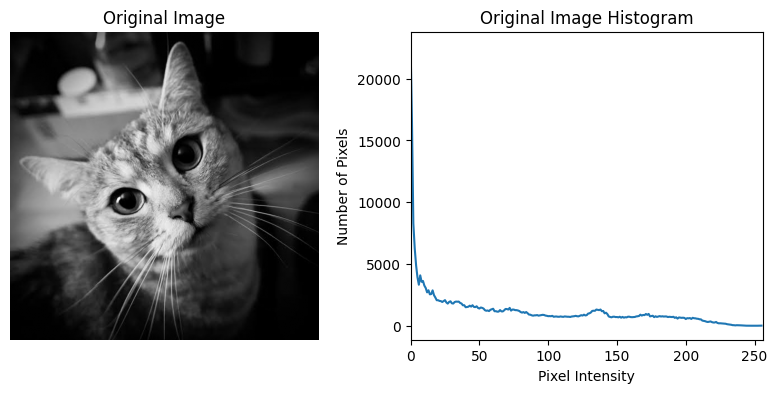

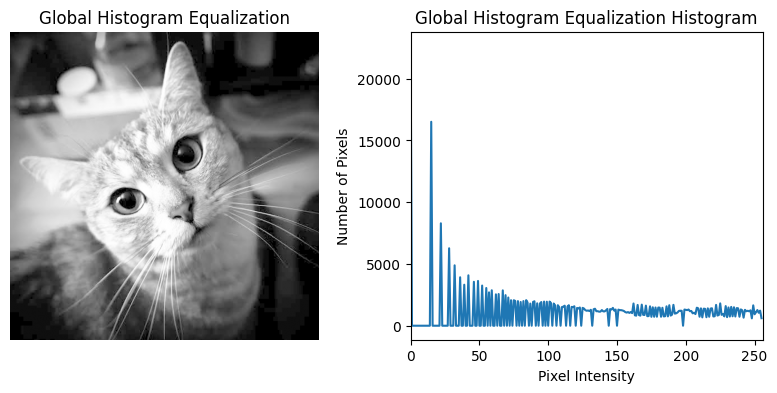

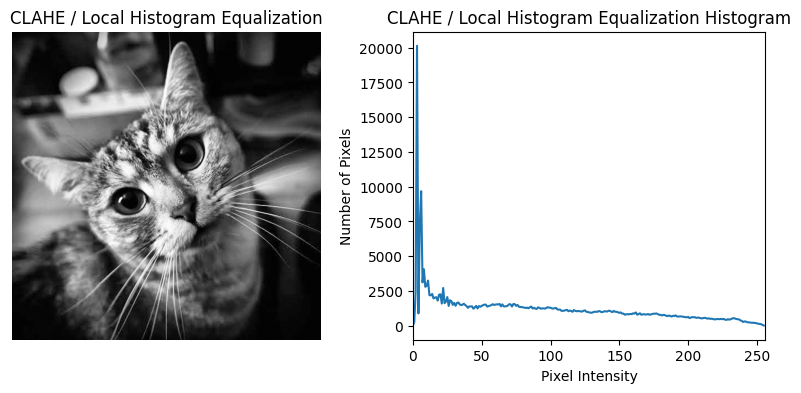

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1) Read image as grayscale
img = cv2.imread("/content/images.jpeg", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Please check image path: sample.jpg")

# 2) Global Histogram Equalization
equalized = cv2.equalizeHist(img)

# 3) Local Histogram Equalization: CLAHE
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)
clahe_img = clahe.apply(img)

# 4) Function for plotting image + histogram
def show_image_and_hist(image, title):
    hist = cv2.calcHist(
        [image],      # image
        [0],          # channel 0 for grayscale
        None,         # no mask
        [256],        # 256 bins
        [0, 256]      # intensity range
    )

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.plot(hist)
    plt.title(title + " Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Number of Pixels")
    plt.xlim([0, 256])

    plt.show()

# 5) Display results
show_image_and_hist(img, "Original Image")
show_image_and_hist(equalized, "Global Histogram Equalization")
show_image_and_hist(clahe_img, "CLAHE / Local Histogram Equalization")

### **Class Discussion**



## 1.   Does Histogram Equalization always improve image quality?


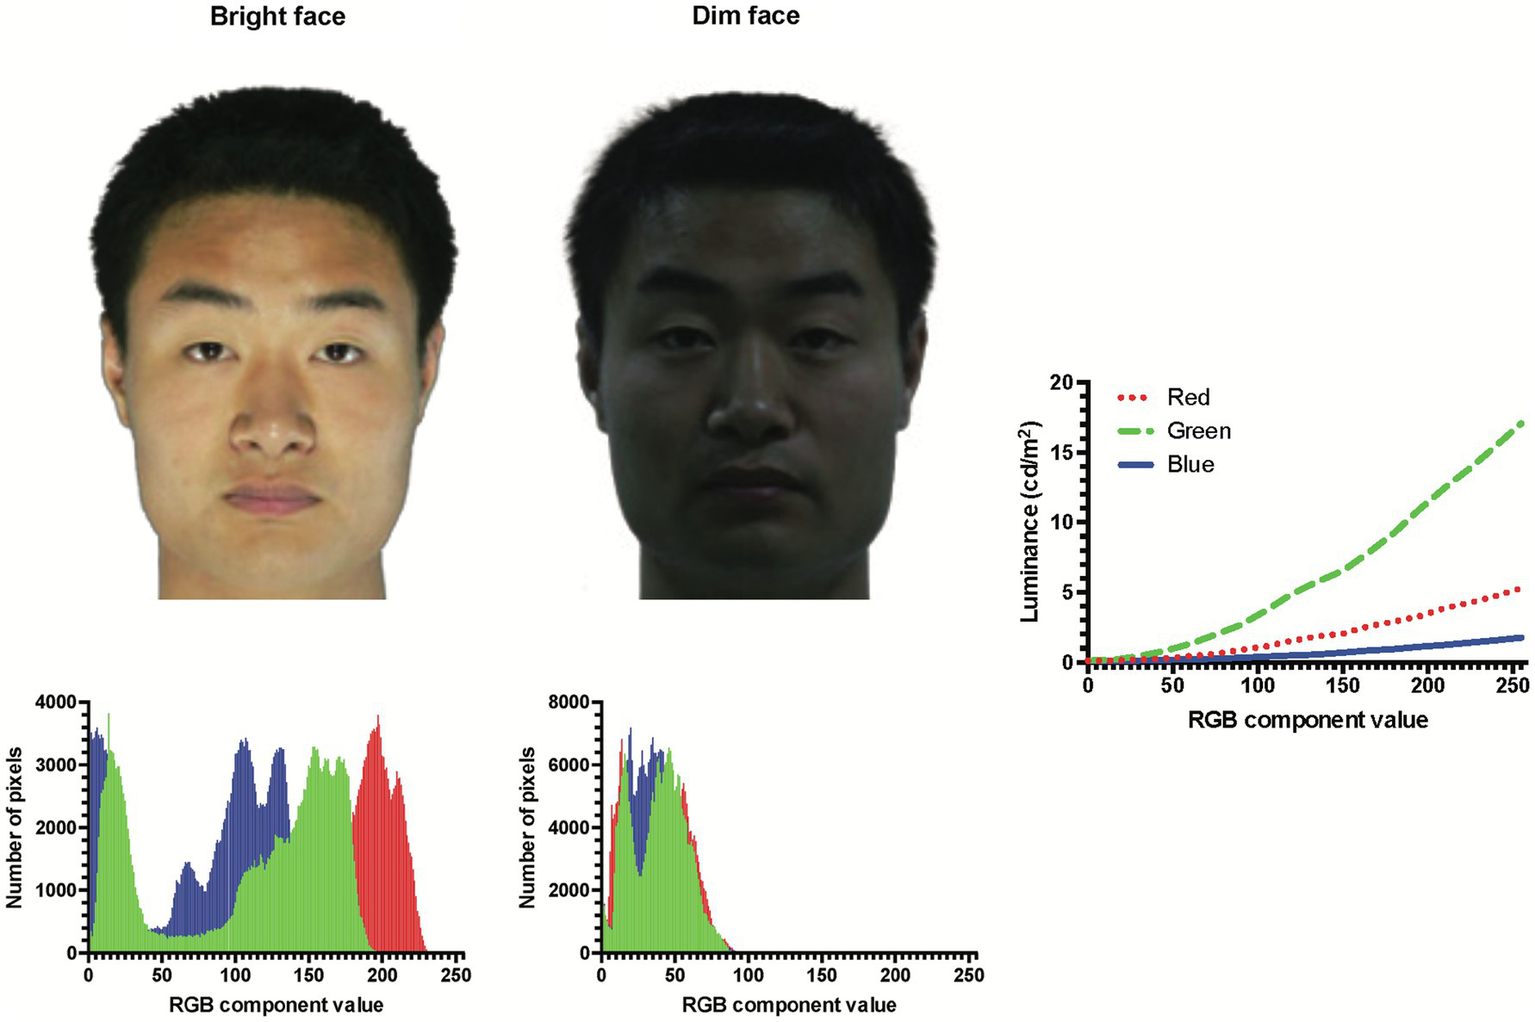

##  If you are building a face recognition system, would you apply Histogram Equalization before training?

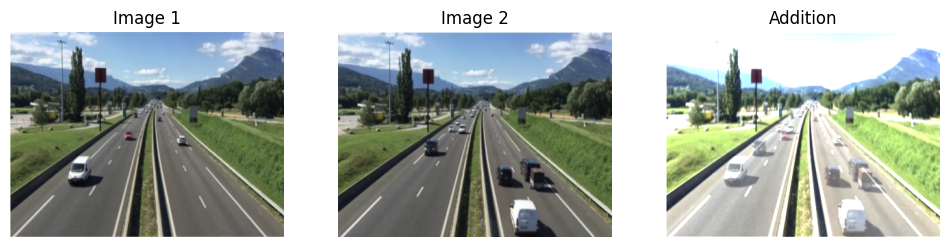

In [ ]:
import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread("/content/img1.png")
img2 = cv2.imread("/content/img2.png")

img1 = cv2.resize(img1, (400,300))
img2 = cv2.resize(img2, (400,300))

result = cv2.add(img1, img2)

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title("Image 1")
plt.axis("off")

plt.subplot(132)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title("Image 2")
plt.axis("off")

plt.subplot(133)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Addition")
plt.axis("off")

plt.show()

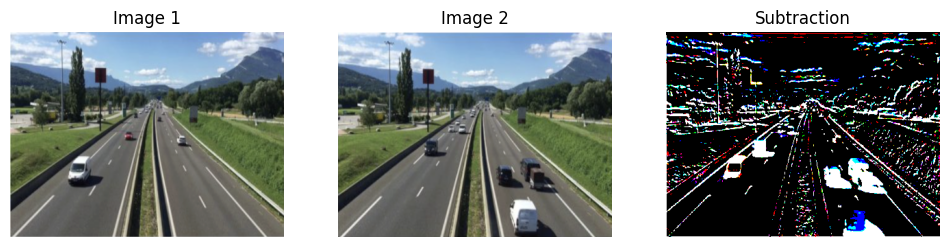

In [ ]:
import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread("/content/img1.png")
img2 = cv2.imread("/content/img2.png")

img1 = cv2.resize(img1,(400,300))
img2 = cv2.resize(img2,(400,300))

result = cv2.subtract(img1, img2)
ret, difference = cv2.threshold(result, 10, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(cv2.cvtColor(img1,cv2.COLOR_BGR2RGB))
plt.title("Image 1")
plt.axis("off")

plt.subplot(132)
plt.imshow(cv2.cvtColor(img2,cv2.COLOR_BGR2RGB))
plt.title("Image 2")
plt.axis("off")

plt.subplot(133)
plt.imshow(difference)
plt.title("Subtraction")
plt.axis("off")

plt.show()

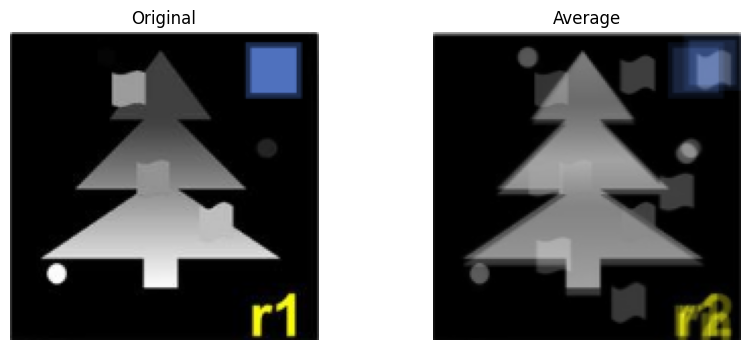

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread("/content/avg1.png")
img2 = cv2.imread("/content/avg2.png")
img3 = cv2.imread("/content/avg3.png")

# Resize images to a common dimension
# Assuming img1's dimensions are the target
height, width, _ = img1.shape
img2 = cv2.resize(img2, (width, height))
img3 = cv2.resize(img3, (width, height))

average = ((img1.astype(np.float32) +
            img2.astype(np.float32) +
            img3.astype(np.float32))/3).astype(np.uint8)

plt.figure(figsize=(10,4))

plt.subplot(121)
plt.imshow(cv2.cvtColor(img1,cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(cv2.cvtColor(average,cv2.COLOR_BGR2RGB))
plt.title("Average")
plt.axis("off")

plt.show()

* Why does averaging reduce random noise?
* What happens if the objects move?



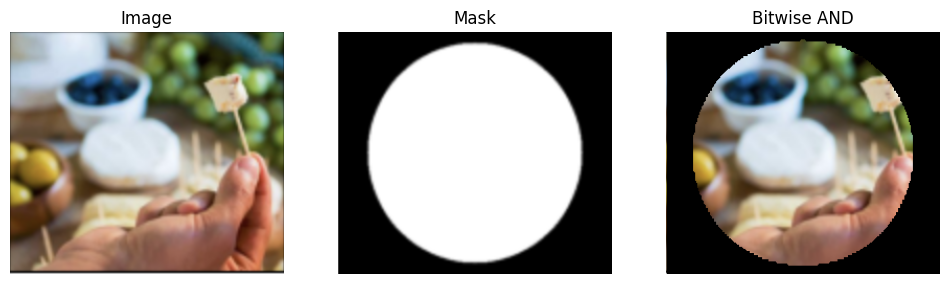

In [ ]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("/content/BW_and.png")
mask = cv2.imread("/content/BW_and_mask.png",0)

mask = cv2.resize(mask,(image.shape[1],image.shape[0]))

result = cv2.bitwise_and(image,image,mask=mask)

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
plt.title("Image")
plt.axis("off")

plt.subplot(132)
plt.imshow(mask,cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(133)
plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))
plt.title("Bitwise AND")
plt.axis("off")

plt.show()

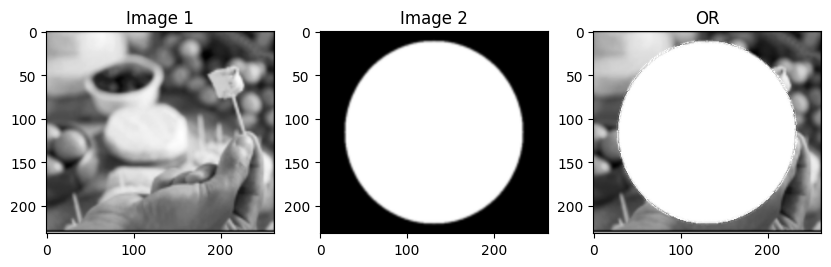

In [ ]:
import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread("/content/BW_and.png",0)
img2 = cv2.imread("/content/BW_and_mask.png",0)

# Ensure both images have the same dimensions
# Resize img2 to match img1's dimensions
img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

result = cv2.bitwise_or(img1,img2)

plt.figure(figsize=(10,4))

plt.subplot(131)
plt.imshow(img1,cmap="gray")

plt.title("Image 1")

plt.subplot(132)
plt.imshow(img2,cmap="gray")

plt.title("Image 2")

plt.subplot(133)
plt.imshow(result,cmap="gray")

plt.title("OR")

plt.show()

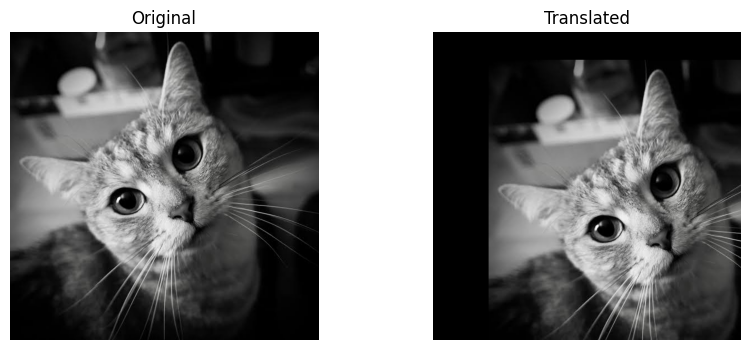

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/images.jpeg")

rows, cols = img.shape[:2]

tx = 100
ty = 50

M = np.float32([
    [1,0,tx],
    [0,1,ty]
])

translated = cv2.warpAffine(img,M,(cols,rows))

plt.figure(figsize=(10,4))

plt.subplot(121)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(cv2.cvtColor(translated,cv2.COLOR_BGR2RGB))
plt.title("Translated")
plt.axis("off")

plt.show()

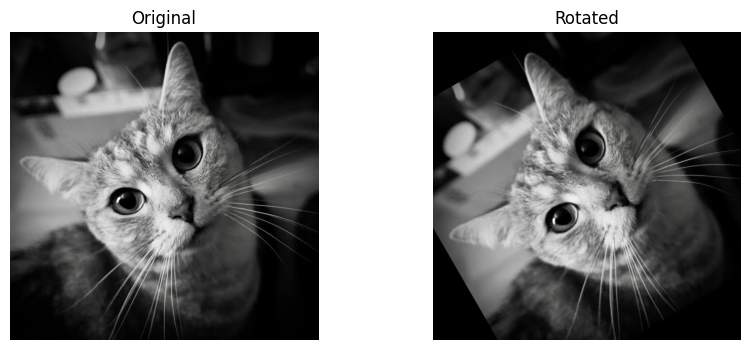

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/images.jpeg")

rows, cols = img.shape[:2]

center = (cols//2, rows//2)

angle = 30

scale = 1

M = cv2.getRotationMatrix2D(center, angle, scale)

rotated = cv2.warpAffine(img,M,(cols,rows))

plt.figure(figsize=(10,4))

plt.subplot(121)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(cv2.cvtColor(rotated,cv2.COLOR_BGR2RGB))
plt.title("Rotated")
plt.axis("off")

plt.show()

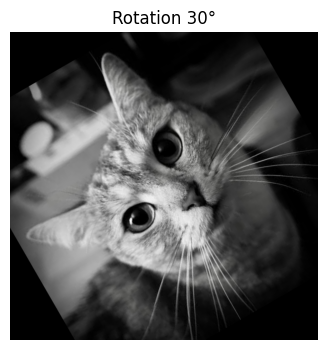

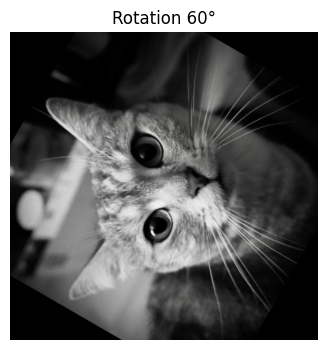

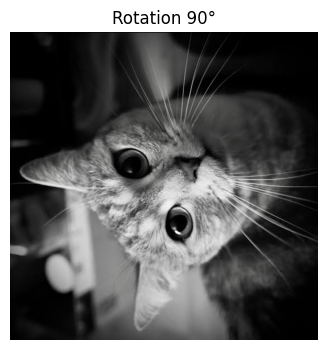

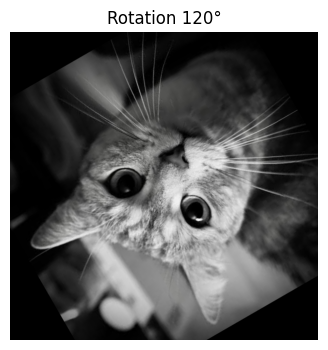

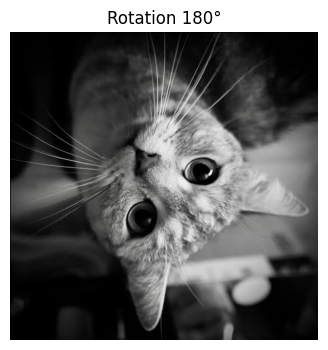

In [ ]:
angles = [30,60,90,120,180]

for angle in angles:

    M = cv2.getRotationMatrix2D(center, angle, 1)

    result = cv2.warpAffine(img, M, (cols, rows))

    plt.figure(figsize=(4,4))
    plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))
    plt.title(f"Rotation {angle}°")
    plt.axis("off")
    plt.show()